# GDV Summary — All Experiments

Three experiment sets, one consistent view.

| Set | Experiments | What varies |
|-----|------------|-------------|
| **Hypotheses** | blank, extreme_negative, extreme_positive, low_negative, low_positive | mental load × emotional valence |
| **Synonym Test** | synonym_5504 (extreme neg) vs original, synonym_7319 (extreme pos) vs original | word choice — synonym replacement |
| **Gender × Emotion** | female/male × 8 emotions | gender and emotion type |

**GDV interpretation:** more negative = better label separation in activation space.
Language layers 44–47 consistently give the best (most negative) GDV across all experiments.


In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'analysis':
    os.chdir('..')
sys.path.insert(0, '.')

import csv, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right'] = False


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
HYPO_DIR  = 'results/metrics'          # blank, extreme_*, low_*
EXP_DIR   = 'results/experiments/metrics'  # synonym_*, gender_*

MOD_ORDER = {'vision': 0, 'projector': 1, 'language': 2, 'unknown': 3}

def _sort_key(lk):
    p = lk.split('_D'); b = p[0]; m, n = b.split('_', 1)
    return (MOD_ORDER.get(m, 3), int(n))

def load_gdv_csv(base, name):
    """Return DataFrame sorted by layer position."""
    p = os.path.join(base, name, 'gdv_values.csv')
    df = pd.read_csv(p)
    df['sort_key'] = df['LayerKey'].apply(_sort_key)
    df['layer_pos'] = df['sort_key'].rank(method='first').astype(int) - 1
    df = df.sort_values('sort_key').reset_index(drop=True)
    return df

def load_gdv_pkl(base, name):
    with open(os.path.join(base, name, 'gdv.pkl'), 'rb') as f:
        return pickle.load(f)

# ── Experiment groups ─────────────────────────────────────────────────────────
HYPO_NAMES = ['blank', 'extreme_negative', 'extreme_positive',
              'low_negative', 'low_positive']
SYN_NAMES  = ['synonym_5504', 'synonym_7319']
GE_NAMES   = ['gender_female_anger', 'gender_female_fear', 'gender_female_disgust',
              'gender_female_sad', 'gender_female_amusement', 'gender_female_awe',
              'gender_female_contentment', 'gender_female_excitement',
              'gender_male_anger']

HYPO_LABELS = {
    'blank':             'Blank (no persona)',
    'extreme_negative':  'Extreme Negative (load=extreme, emotion=anger)',
    'extreme_positive':  'Extreme Positive (load=extreme, emotion=excitement)',
    'low_negative':      'Low Negative (load=low, emotion=fear)',
    'low_positive':      'Low Positive (load=low, emotion=amusement)',
}
SYN_LABELS = {
    'synonym_5504': 'Synonym 5504 (extreme neg → synonym)',
    'synonym_7319': 'Synonym 7319 (extreme pos → synonym)',
}
GE_LABELS = {
    'gender_female_anger':       'F-Anger',
    'gender_female_fear':        'F-Fear',
    'gender_female_disgust':     'F-Disgust',
    'gender_female_sad':         'F-Sad',
    'gender_female_amusement':   'F-Amusement',
    'gender_female_awe':         'F-Awe',
    'gender_female_contentment': 'F-Contentment',
    'gender_female_excitement':  'F-Excitement',
    'gender_male_anger':         'M-Anger',
}

# ── Modality shading helper ───────────────────────────────────────────────────
MOD_COLORS = {'vision': '#e8f4fd', 'projector': '#fff3cd', 'language': '#e8f8e8'}

def shade_modalities(ax, ref_df):
    prev_mod, start = None, 0
    for _, row in ref_df.iterrows():
        mod = row['Modality']
        pos = row['layer_pos']
        if mod != prev_mod:
            if prev_mod is not None:
                ax.axvspan(start - 0.5, pos - 0.5,
                           color=MOD_COLORS.get(prev_mod, '#f0f0f0'), alpha=0.35, zorder=0)
            prev_mod, start = mod, pos
    if prev_mod is not None:
        ax.axvspan(start - 0.5, ref_df['layer_pos'].max() + 0.5,
                   color=MOD_COLORS.get(prev_mod, '#f0f0f0'), alpha=0.35, zorder=0)

print("Setup complete.")


Setup complete.


In [3]:
# Load reference layer order (same for all experiments — 82 layers)
ref_df = load_gdv_csv(HYPO_DIR, 'blank')
layer_keys = ref_df['LayerKey'].tolist()
layer_pos  = ref_df['layer_pos'].tolist()
tick_pos   = layer_pos[::4]
tick_labs  = [layer_keys[i] for i in range(0, len(layer_keys), 4)]

def apply_layer_xticks(ax, fontsize=6):
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labs, rotation=45, ha='right', fontsize=fontsize)

def add_mod_legend(ax):
    patches = [mpatches.Patch(color=MOD_COLORS[m], alpha=0.6, label=m.capitalize())
               for m in ('vision', 'projector', 'language')]
    ax.legend(handles=patches + ax.get_legend_handles_labels()[0],
              labels=['Vision', 'Projector', 'Language'] + ax.get_legend_handles_labels()[1],
              bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

print(f"Layer order: {len(layer_keys)} layers  (same across all experiment sets)")
print("First 5:", layer_keys[:5])
print("Last 5:", layer_keys[-5:])


Layer order: 82 layers  (same across all experiment sets)
First 5: ['vision_0_D1408', 'vision_1_D1408', 'vision_2_D1408', 'vision_3_D1408', 'vision_4_D1408']
Last 5: ['language_43_D5120', 'language_44_D5120', 'language_45_D5120', 'language_46_D5120', 'language_47_D5120']


---
## 1. Hypothesis Experiments — GDV Across All Layers

**Five conditions:**
- **Blank** — no persona, baseline
- **Extreme Negative** — extreme mental load + anger (persona 5504)
- **Extreme Positive** — extreme mental load + excitement (persona 7319)
- **Low Negative** — low mental load + fear (persona 3770)
- **Low Positive** — low mental load + amusement (persona 8447)

**Hypothesis:** extreme mental load and/or negative valence should push interestingness
labels toward one end of the scale → clearer label separation → more negative GDV.


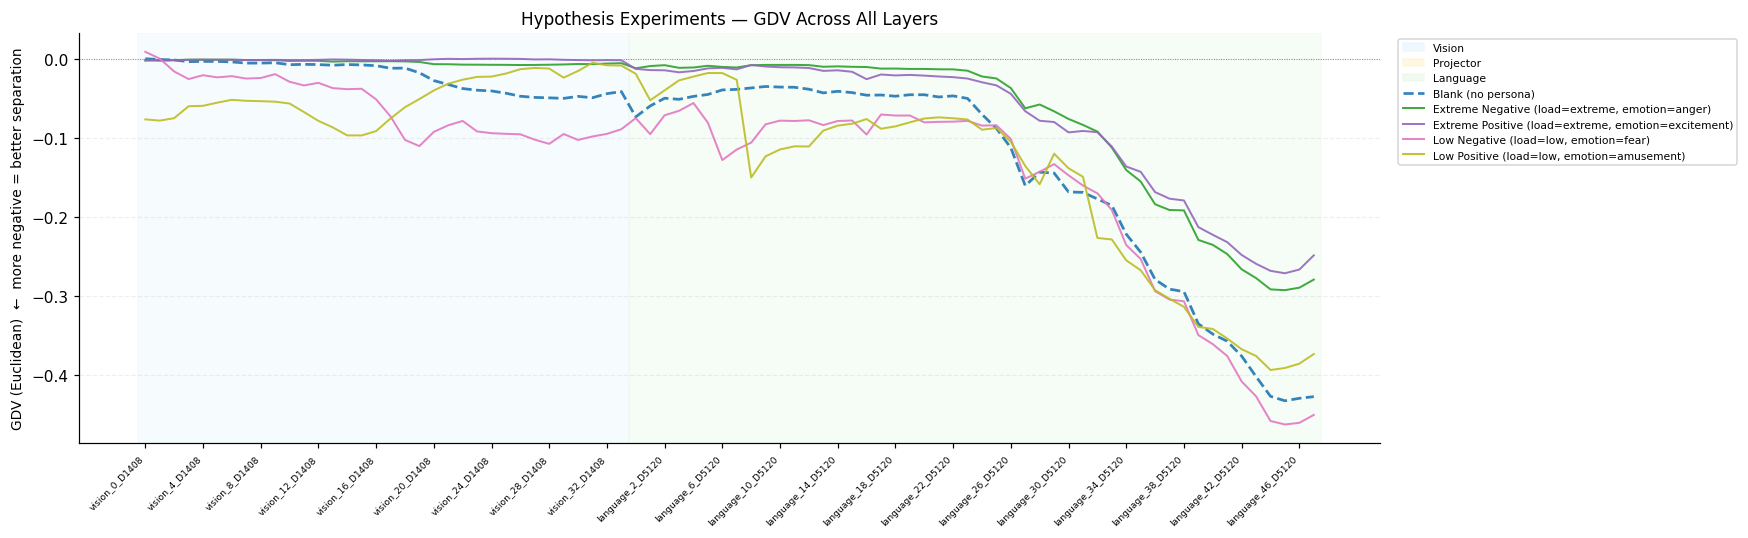

In [4]:
cmap_hypo = plt.colormaps['tab10']
fig, ax   = plt.subplots(figsize=(16, 5))
shade_modalities(ax, ref_df)
ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)

hypo_dfs = {}
for i, name in enumerate(HYPO_NAMES):
    df  = load_gdv_csv(HYPO_DIR, name)
    gdv = df.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
    hypo_dfs[name] = gdv
    style = '-' if name != 'blank' else '--'
    lw    = 1.8 if name == 'blank' else 1.3
    ax.plot(layer_pos, gdv, style, color=cmap_hypo(i / len(HYPO_NAMES)),
            linewidth=lw, label=HYPO_LABELS[name], alpha=0.9)

apply_layer_xticks(ax)
ax.set_ylabel('GDV (Euclidean)  ←  more negative = better separation', fontsize=9)
ax.set_title('Hypothesis Experiments — GDV Across All Layers', fontsize=11)
ax.grid(axis='y', alpha=0.2, linestyle='--')
add_mod_legend(ax)
plt.tight_layout()
plt.savefig('results/summary_gdv_hypotheses.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Best-layer summary table for hypotheses
print(f"{'Condition':<50}  {'Best GDV':>10}  {'Best Layer'}")
print('-' * 90)
for name in HYPO_NAMES:
    df  = load_gdv_csv(HYPO_DIR, name)
    row = df.loc[df['GDV_Euclidean'].idxmin()]
    print(f"{HYPO_LABELS[name]:<50}  {row['GDV_Euclidean']:>10.4f}  {row['LayerKey']}")


Condition                                             Best GDV  Best Layer
------------------------------------------------------------------------------------------
Blank (no persona)                                     -0.4325  language_45_D5120
Extreme Negative (load=extreme, emotion=anger)         -0.2927  language_45_D5120
Extreme Positive (load=extreme, emotion=excitement)     -0.2713  language_45_D5120
Low Negative (load=low, emotion=fear)                  -0.4624  language_45_D5120
Low Positive (load=low, emotion=amusement)             -0.3936  language_44_D5120


---
## 2. Synonym Test — GDV Across All Layers

**Question:** does changing synonymous words in the persona description shift the
model's interestingness judgements?

Each synonym experiment is compared against its **original persona** (5504 = extreme
negative, 7319 = extreme positive) on the same 500 images.


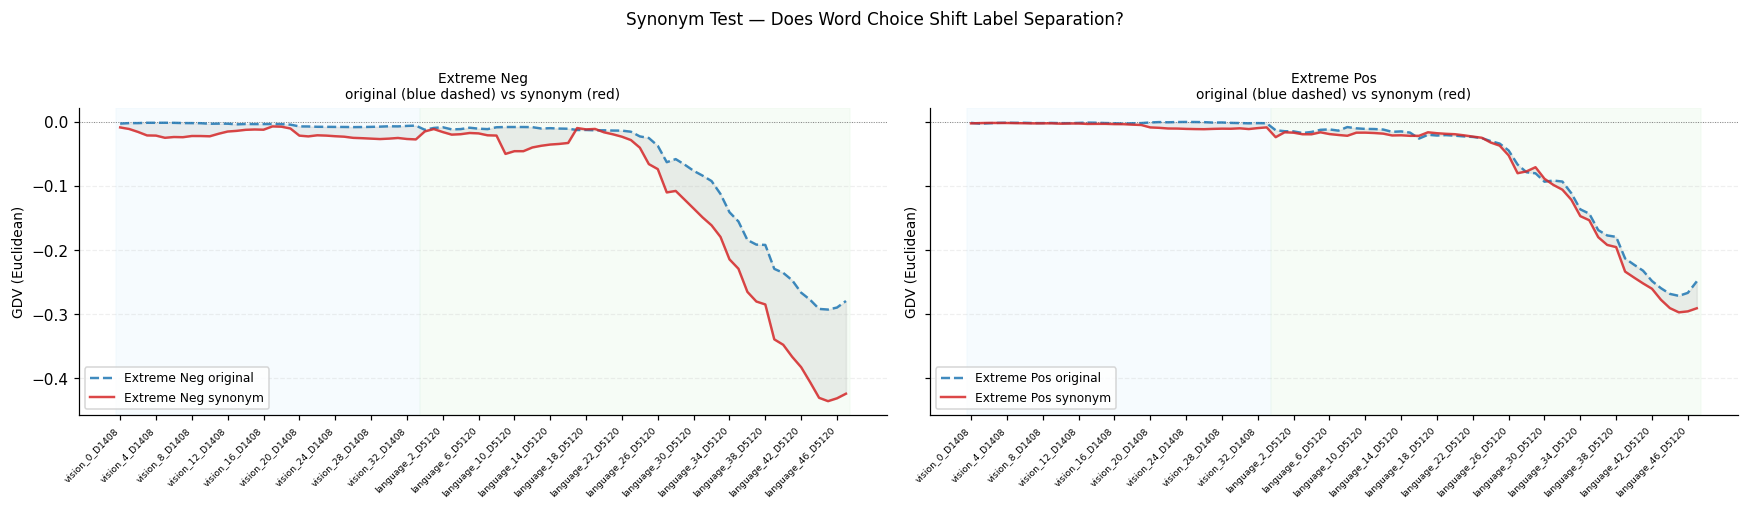

In [6]:
# Load synonym + their original counterparts for direct comparison
SYN_PAIRS = [
    ('extreme_negative', 'synonym_5504', 'Extreme Neg original', 'Extreme Neg synonym'),
    ('extreme_positive', 'synonym_7319', 'Extreme Pos original', 'Extreme Pos synonym'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)

for ax, (orig_name, syn_name, orig_lab, syn_lab) in zip(axes, SYN_PAIRS):
    shade_modalities(ax, ref_df)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)

    # Original
    df_orig = load_gdv_csv(HYPO_DIR, orig_name)
    gdv_orig = df_orig.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
    ax.plot(layer_pos, gdv_orig, '--', color='#1f77b4', linewidth=1.6,
            label=orig_lab, alpha=0.85)

    # Synonym
    df_syn  = load_gdv_csv(EXP_DIR, syn_name)
    gdv_syn = df_syn.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
    ax.plot(layer_pos, gdv_syn, '-',  color='#d62728', linewidth=1.6,
            label=syn_lab, alpha=0.85)

    # Fill area between curves to show difference
    ax.fill_between(layer_pos, gdv_orig, gdv_syn, alpha=0.12, color='grey')

    apply_layer_xticks(ax, fontsize=6)
    ax.set_title(f'{orig_lab.split()[0]} {orig_lab.split()[1]}\n'
                 f'original (blue dashed) vs synonym (red)', fontsize=9)
    ax.set_ylabel('GDV (Euclidean)', fontsize=9)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Synonym Test — Does Word Choice Shift Label Separation?', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('results/summary_gdv_synonym.png', dpi=150, bbox_inches='tight')
plt.show()


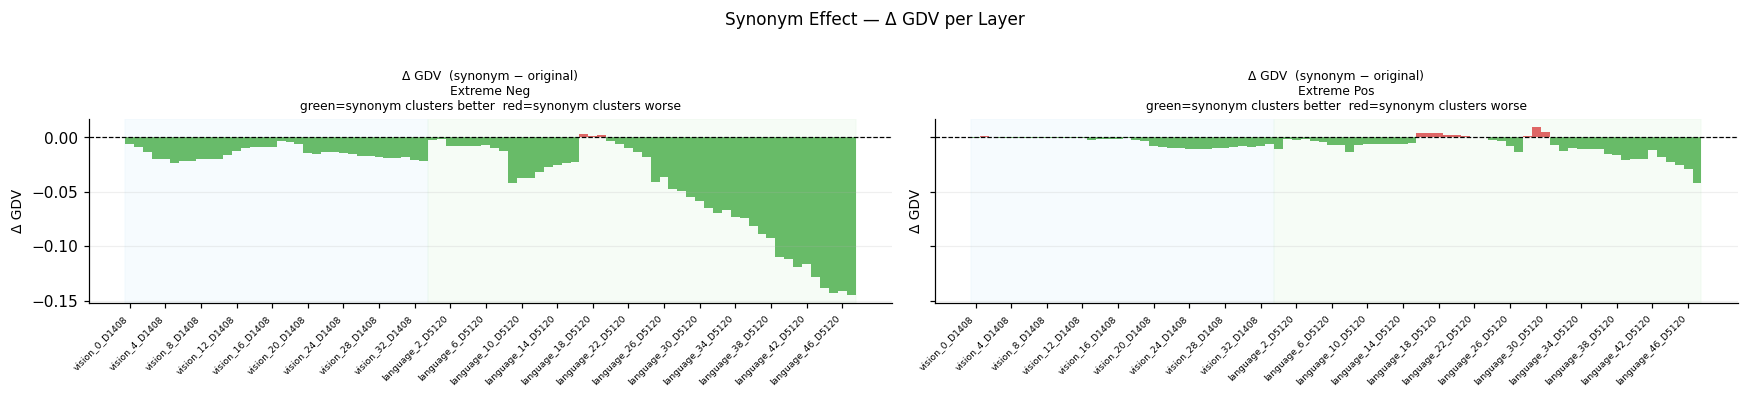

In [7]:
# Difference plot: synonym − original (per layer)
fig, axes = plt.subplots(1, 2, figsize=(16, 3.5), sharey=True)

for ax, (orig_name, syn_name, orig_lab, syn_lab) in zip(axes, SYN_PAIRS):
    shade_modalities(ax, ref_df)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    df_orig = load_gdv_csv(HYPO_DIR, orig_name)
    df_syn  = load_gdv_csv(EXP_DIR,  syn_name)
    gdv_orig = df_orig.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
    gdv_syn  = df_syn.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
    diff     = gdv_syn - gdv_orig

    colors = ['#2ca02c' if d < 0 else '#d62728' for d in diff]
    ax.bar(layer_pos, diff, color=colors, alpha=0.7, width=1.0)
    apply_layer_xticks(ax, fontsize=6)
    ax.set_title(f'Δ GDV  (synonym − original)\n{orig_lab.split()[0]} {orig_lab.split()[1]}\n'
                 f'green=synonym clusters better  red=synonym clusters worse', fontsize=8)
    ax.set_ylabel('Δ GDV', fontsize=9)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Synonym Effect — Δ GDV per Layer', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('results/summary_gdv_synonym_diff.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Summary table
print(f"{'Condition':<35}  {'Best GDV':>10}  {'Best Layer':<30}  {'Δ best GDV vs original':>22}")
print('-' * 105)
for orig_name, syn_name, orig_lab, syn_lab in SYN_PAIRS:
    df_o = load_gdv_csv(HYPO_DIR, orig_name)
    df_s = load_gdv_csv(EXP_DIR,  syn_name)
    best_o = df_o.loc[df_o['GDV_Euclidean'].idxmin()]
    best_s = df_s.loc[df_s['GDV_Euclidean'].idxmin()]
    delta  = best_s['GDV_Euclidean'] - best_o['GDV_Euclidean']
    print(f"{orig_lab:<35}  {best_o['GDV_Euclidean']:>10.4f}  {best_o['LayerKey']:<30}")
    print(f"{syn_lab:<35}  {best_s['GDV_Euclidean']:>10.4f}  {best_s['LayerKey']:<30}  {delta:>+22.4f}")
    print()


Condition                              Best GDV  Best Layer                      Δ best GDV vs original
---------------------------------------------------------------------------------------------------------
Extreme Neg original                    -0.2927  language_45_D5120             
Extreme Neg synonym                     -0.4355  language_45_D5120                              -0.1428

Extreme Pos original                    -0.2713  language_45_D5120             
Extreme Pos synonym                     -0.2970  language_45_D5120                              -0.0257



---
## 3. Gender × Emotion — GDV Across All Layers

Nine conditions: eight female emotions + male anger.

**Key comparisons:**
- Female anger vs male anger → gender effect on same emotion
- Negative emotions (anger, fear, disgust, sad) vs positive (amusement, awe, contentment, excitement) → valence effect


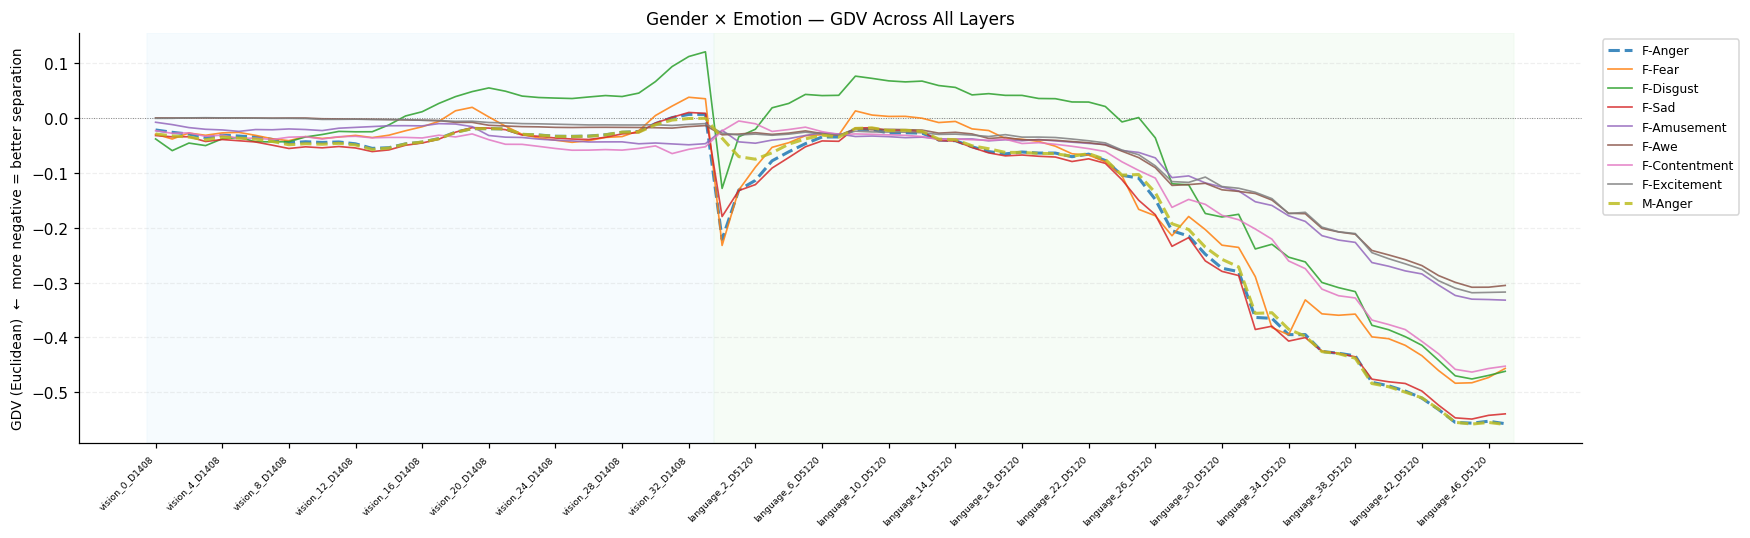

In [9]:
cmap_ge = plt.colormaps['tab10']
fig, ax  = plt.subplots(figsize=(16, 5))
shade_modalities(ax, ref_df)
ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)

for i, name in enumerate(GE_NAMES):
    df  = load_gdv_csv(EXP_DIR, name)
    gdv = df.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
    style = '--' if 'male_anger' in name else '-'
    lw    = 2.0 if name in ('gender_female_anger', 'gender_male_anger') else 1.1
    ax.plot(layer_pos, gdv, style, color=cmap_ge(i / len(GE_NAMES)),
            linewidth=lw, label=GE_LABELS[name], alpha=0.85)

apply_layer_xticks(ax)
ax.set_ylabel('GDV (Euclidean)  ←  more negative = better separation', fontsize=9)
ax.set_title('Gender × Emotion — GDV Across All Layers', fontsize=11)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('results/summary_gdv_gender_emotion.png', dpi=150, bbox_inches='tight')
plt.show()


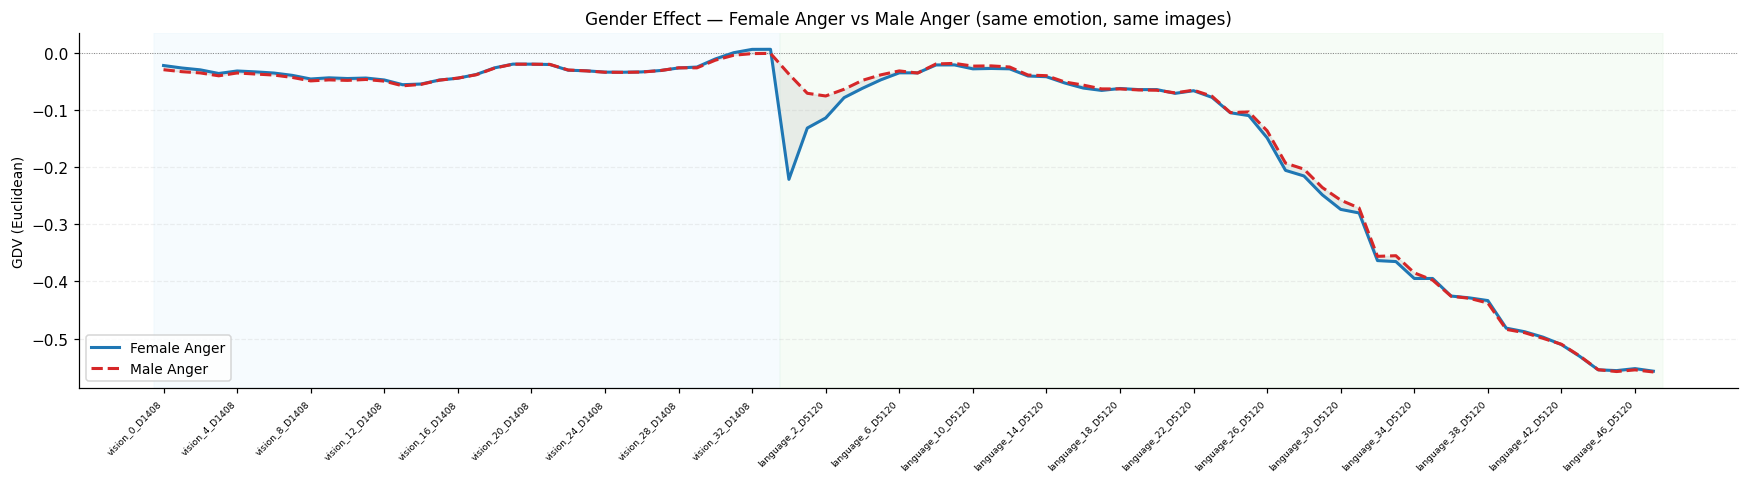

In [10]:
# Female anger vs Male anger overlay — highlight gender effect
fig, ax = plt.subplots(figsize=(16, 4.5))
shade_modalities(ax, ref_df)
ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)

df_fa = load_gdv_csv(EXP_DIR, 'gender_female_anger')
df_ma = load_gdv_csv(EXP_DIR, 'gender_male_anger')
gdv_fa = df_fa.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values
gdv_ma = df_ma.set_index('LayerKey').reindex(layer_keys)['GDV_Euclidean'].values

ax.plot(layer_pos, gdv_fa, '-',  color='#1f77b4', linewidth=2.0, label='Female Anger')
ax.plot(layer_pos, gdv_ma, '--', color='#d62728', linewidth=2.0, label='Male Anger')
ax.fill_between(layer_pos, gdv_fa, gdv_ma, alpha=0.12, color='grey')

apply_layer_xticks(ax)
ax.set_ylabel('GDV (Euclidean)', fontsize=9)
ax.set_title('Gender Effect — Female Anger vs Male Anger (same emotion, same images)',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('results/summary_gdv_gender_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Best-layer summary for gender × emotion
print(f"{'Condition':<20}  {'Best GDV':>10}  {'Best Layer'}")
print('-' * 65)
for name in GE_NAMES:
    df  = load_gdv_csv(EXP_DIR, name)
    row = df.loc[df['GDV_Euclidean'].idxmin()]
    print(f"{GE_LABELS[name]:<20}  {row['GDV_Euclidean']:>10.4f}  {row['LayerKey']}")


Condition               Best GDV  Best Layer
-----------------------------------------------------------------
F-Anger                  -0.5569  language_47_D5120
F-Fear                   -0.4832  language_44_D5120
F-Disgust                -0.4755  language_45_D5120
F-Sad                    -0.5484  language_45_D5120
F-Amusement              -0.3320  language_47_D5120
F-Awe                    -0.3086  language_45_D5120
F-Contentment            -0.4629  language_45_D5120
F-Excitement             -0.3185  language_45_D5120
M-Anger                  -0.5583  language_47_D5120


---
## 4. Cross-Experiment Comparison

All three experiment sets on a single axes — normalised to the same y-scale.
This gives a direct sense of how much label separation each experimental
manipulation produces relative to the others.


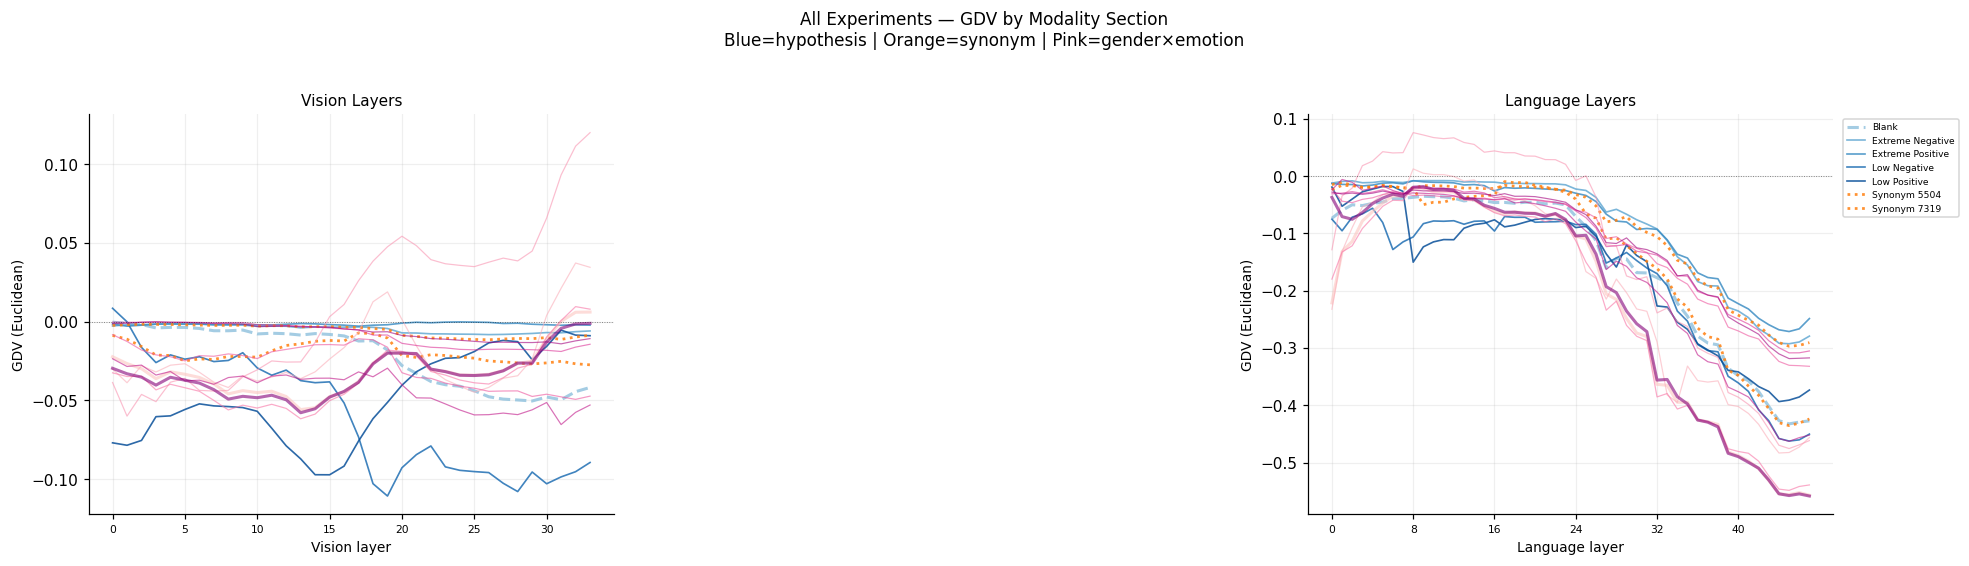

In [12]:
# All experiments together — one panel per modality section
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
modalities = [('vision', 'Vision Layers'), ('projector', 'Projector Layers'), ('language', 'Language Layers')]

for ax, (mod, mod_title) in zip(axes, modalities):
    mod_keys = [k for k in layer_keys if k.startswith(mod)]
    mod_pos  = [ref_df.loc[ref_df['LayerKey']==k, 'layer_pos'].values[0] for k in mod_keys]
    if not mod_keys:
        ax.set_visible(False); continue

    # Hypothesis (solid, cool colours)
    cmap_h = plt.colormaps['Blues']
    for i, name in enumerate(HYPO_NAMES):
        df  = load_gdv_csv(HYPO_DIR, name)
        gdv = df.set_index('LayerKey').reindex(mod_keys)['GDV_Euclidean'].values
        lw  = 2.0 if name == 'blank' else 1.1
        ls  = '--' if name == 'blank' else '-'
        ax.plot(mod_pos, gdv, ls, color=cmap_h(0.4 + 0.12*i),
                linewidth=lw, label=HYPO_LABELS[name].split('(')[0].strip(), alpha=0.85)

    # Synonym (dotted, orange)
    for name, lbl in SYN_LABELS.items():
        df  = load_gdv_csv(EXP_DIR, name)
        gdv = df.set_index('LayerKey').reindex(mod_keys)['GDV_Euclidean'].values
        ax.plot(mod_pos, gdv, ':', color='#ff7f0e', linewidth=1.8,
                label=lbl.split('(')[0].strip(), alpha=0.85)

    # Gender × Emotion (dashed, red/purple range)
    cmap_ge2 = plt.colormaps['RdPu']
    for i, name in enumerate(GE_NAMES):
        df  = load_gdv_csv(EXP_DIR, name)
        gdv = df.set_index('LayerKey').reindex(mod_keys)['GDV_Euclidean'].values
        lw  = 2.0 if name in ('gender_female_anger','gender_male_anger') else 0.8
        ax.plot(mod_pos, gdv, '-', color=cmap_ge2(0.25 + 0.075*i),
                linewidth=lw, alpha=0.6)

    ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)
    x_step = max(1, len(mod_pos) // 6)
    ax.set_xticks(mod_pos[::x_step])
    ax.set_xticklabels([k.split('_')[1] for k in mod_keys[::x_step]],
                       rotation=0, fontsize=7)
    ax.set_xlabel(f'{mod.capitalize()} layer', fontsize=9)
    ax.set_ylabel('GDV (Euclidean)', fontsize=9)
    ax.set_title(mod_title, fontsize=10)
    ax.grid(alpha=0.2)
    if mod == 'language':
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

plt.suptitle('All Experiments — GDV by Modality Section\n'
             'Blue=hypothesis | Orange=synonym | Pink=gender×emotion',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('results/summary_gdv_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. GDV Distribution — All Experiments (Box Plot)

Each box shows the distribution of GDV values **across all 82 layers** for that experiment:
- Box = IQR (25th–75th percentile)
- Centre line = median
- Whiskers = 1.5 × IQR
- Dots = outlier layers

Experiments are grouped by set and sorted by median GDV within each group.
This reveals both how well an experiment separates labels at its best layer
*and* how consistent the separation is across the full layer hierarchy.


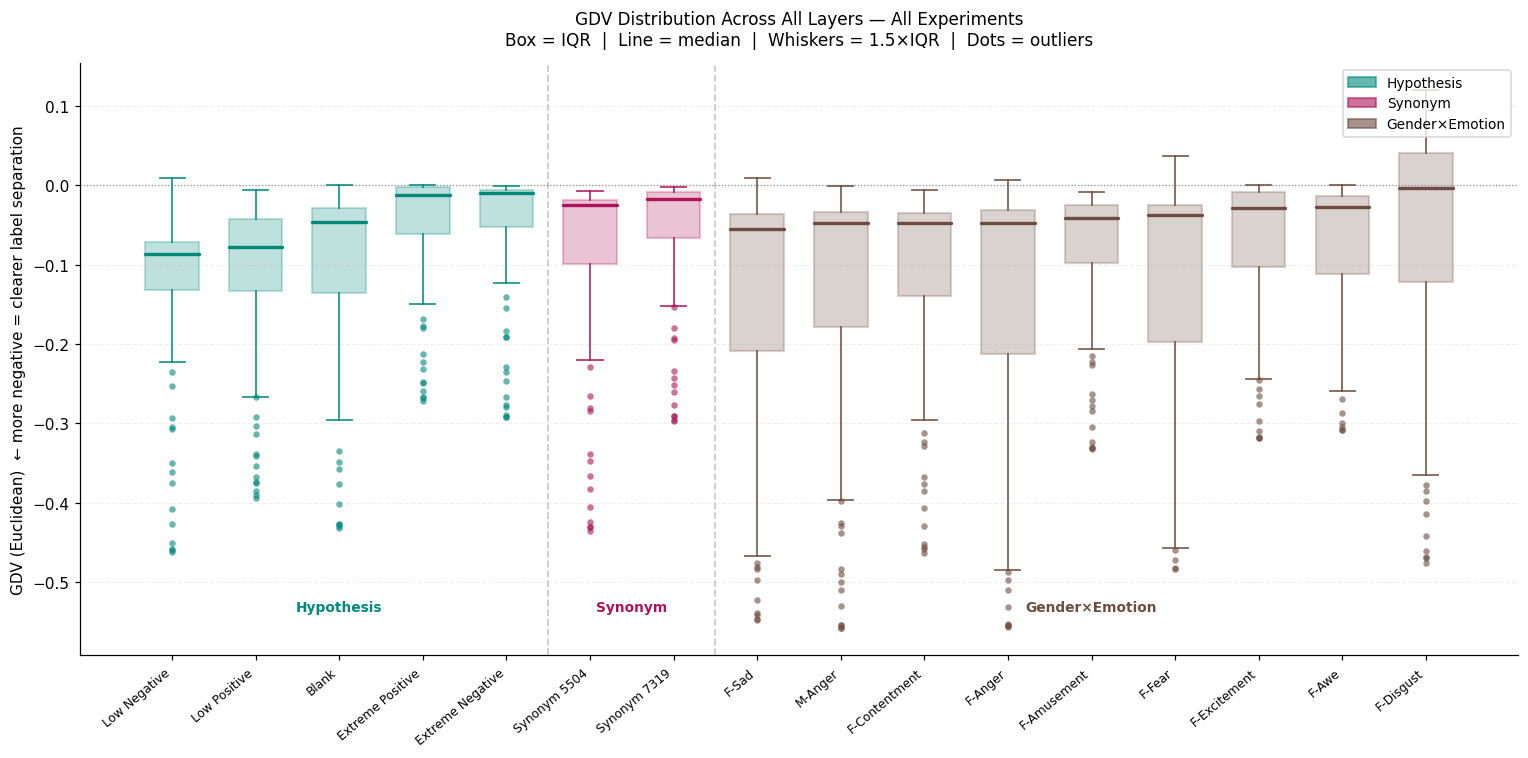

In [13]:
# Custom palette — teal / magenta / sienna
# Nothing in the existing visualisations uses these hues
SET_COLORS = {
    'Hypothesis':     '#00897B',  # teal
    'Synonym':        '#AD1457',  # magenta / deep rose
    'Gender×Emotion': '#6D4C41',  # sienna / warm brown
}

# Collect per-experiment full GDV distributions
all_rows = []

for name in HYPO_NAMES:
    df = load_gdv_csv(HYPO_DIR, name)
    for v in df['GDV_Euclidean']:
        all_rows.append({'Set': 'Hypothesis',
                         'Experiment': HYPO_LABELS[name].split('(')[0].strip(),
                         'GDV': v})

for name in SYN_NAMES:
    df = load_gdv_csv(EXP_DIR, name)
    for v in df['GDV_Euclidean']:
        all_rows.append({'Set': 'Synonym',
                         'Experiment': SYN_LABELS[name].split('(')[0].strip(),
                         'GDV': v})

for name in GE_NAMES:
    df = load_gdv_csv(EXP_DIR, name)
    for v in df['GDV_Euclidean']:
        all_rows.append({'Set': 'Gender×Emotion',
                         'Experiment': GE_LABELS[name],
                         'GDV': v})

dist_df = pd.DataFrame(all_rows)

# Sort experiments within each set by median GDV (most negative first)
exp_order = (dist_df.groupby('Experiment')['GDV']
             .median()
             .sort_values()          # ascending = most negative first
             .index.tolist())

# Set order for grouping
set_order  = ['Hypothesis', 'Synonym', 'Gender×Emotion']
set_medians = dist_df.groupby('Set')['GDV'].median().reindex(set_order)
exp_sets   = dist_df.drop_duplicates('Experiment').set_index('Experiment')['Set']

# Build final x-order: group by set, within-set sorted by median
ordered_exps = []
for s in set_order:
    in_set = [e for e in exp_order if exp_sets.get(e) == s]
    ordered_exps.extend(in_set)

# ── Draw box plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

for xi, exp in enumerate(ordered_exps):
    vals   = dist_df.loc[dist_df['Experiment'] == exp, 'GDV'].values
    s      = exp_sets[exp]
    col    = SET_COLORS[s]
    alpha  = 0.85

    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr   = q3 - q1
    lo    = max(vals.min(), q1 - 1.5*iqr)
    hi    = min(vals.max(), q3 + 1.5*iqr)
    outliers = vals[(vals < lo) | (vals > hi)]

    # Box
    box = plt.Rectangle((xi - 0.32, q1), 0.64, iqr,
                         facecolor=col, alpha=0.25, edgecolor=col, linewidth=1.4)
    ax.add_patch(box)
    # Median line
    ax.plot([xi - 0.32, xi + 0.32], [med, med],
            color=col, linewidth=2.2, solid_capstyle='round')
    # Whiskers
    ax.plot([xi, xi], [lo, q1], color=col, linewidth=1.2, alpha=alpha)
    ax.plot([xi, xi], [q3, hi], color=col, linewidth=1.2, alpha=alpha)
    ax.plot([xi - 0.15, xi + 0.15], [lo, lo], color=col, linewidth=1.2, alpha=alpha)
    ax.plot([xi - 0.15, xi + 0.15], [hi, hi], color=col, linewidth=1.2, alpha=alpha)
    # Outlier dots
    if len(outliers):
        ax.scatter([xi]*len(outliers), outliers, color=col, s=18,
                   alpha=0.6, zorder=4, linewidths=0)

# ── Group separators and labels ───────────────────────────────────────────────
set_positions = {}
for s in set_order:
    idxs = [i for i, e in enumerate(ordered_exps) if exp_sets[e] == s]
    set_positions[s] = idxs

for s in set_order[:-1]:
    sep = set_positions[s][-1] + 0.5
    ax.axvline(sep, color='#cccccc', linewidth=1.2, linestyle='--', zorder=0)

for s in set_order:
    idxs  = set_positions[s]
    mid   = (idxs[0] + idxs[-1]) / 2
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 0.12
    ax.text(mid, ax.get_ylim()[1] if hasattr(ax, '_y_set') else 0.07,
            s, ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=SET_COLORS[s], transform=ax.get_xaxis_transform())

ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':', zorder=1)
ax.set_xticks(range(len(ordered_exps)))
ax.set_xticklabels(ordered_exps, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('GDV (Euclidean)  ← more negative = clearer label separation', fontsize=10)
ax.set_title('GDV Distribution Across All Layers — All Experiments\n'
             'Box = IQR  |  Line = median  |  Whiskers = 1.5×IQR  |  Dots = outliers',
             fontsize=11, pad=12)
ax.grid(axis='y', alpha=0.2, linestyle='--')

handles = [mpatches.Patch(facecolor=SET_COLORS[s], alpha=0.6, edgecolor=SET_COLORS[s],
                          linewidth=1.2, label=s)
           for s in set_order]
ax.legend(handles=handles, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('results/summary_best_gdv_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Interestingness Label Distribution — All Experiments

Stacked bars showing the percentage of each interestingness label per experiment.
Background shading marks the experiment set (teal=Hypothesis, magenta=Synonym, sienna=Gender×Emotion).


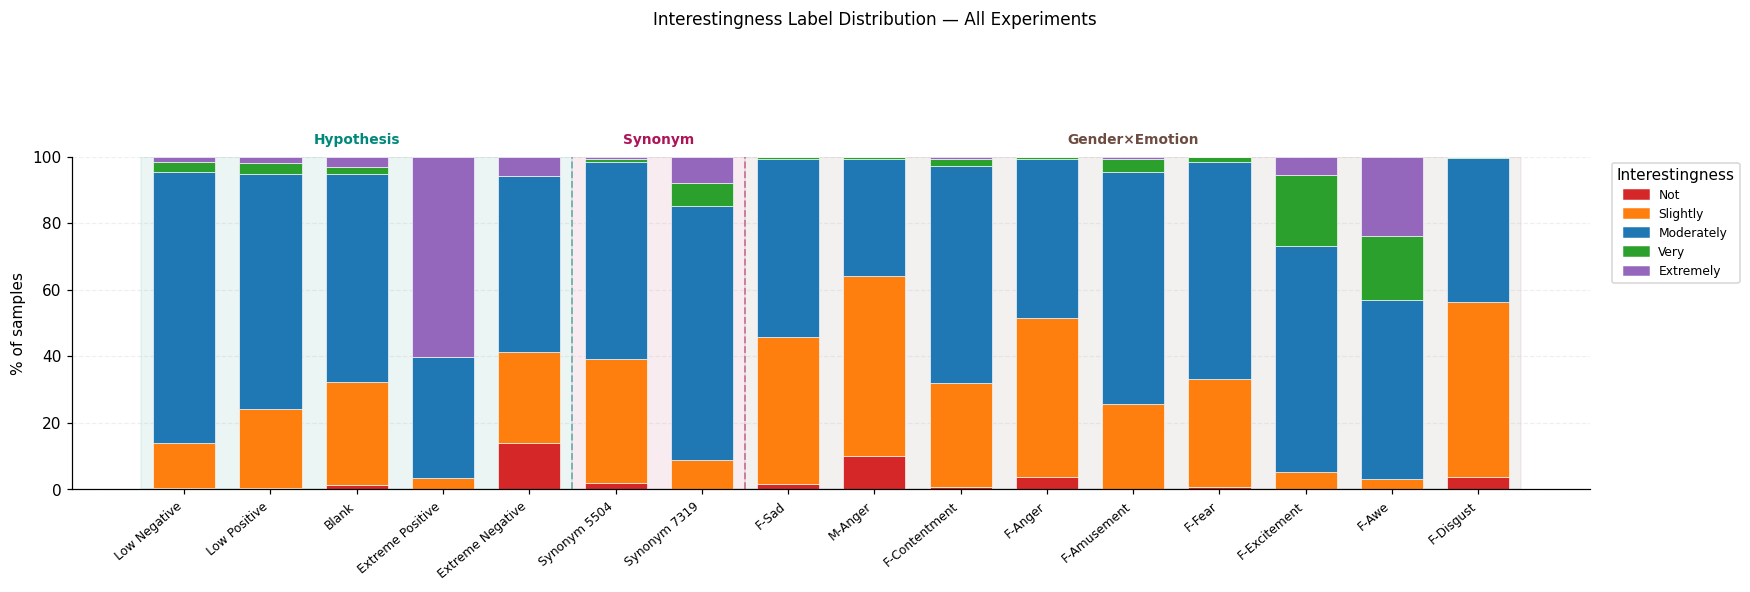

In [14]:
# ── File paths for each display name ─────────────────────────────────────────
DATA_PATHS = {}
DATA_PATHS.update({
    HYPO_LABELS['blank'].split('(')[0].strip():
        ('data/results_blank_activations.npy', None),
    HYPO_LABELS['extreme_negative'].split('(')[0].strip():
        ('data/results_persona_5504.npy', None),
    HYPO_LABELS['extreme_positive'].split('(')[0].strip():
        ('data/results_persona_7319.npy', None),
    HYPO_LABELS['low_negative'].split('(')[0].strip():
        ('data/results_persona_3770.npy', None),
    HYPO_LABELS['low_positive'].split('(')[0].strip():
        ('data/results_persona_8447.npy', None),
})
DATA_PATHS.update({
    SYN_LABELS['synonym_5504'].split('(')[0].strip():
        ('data/experiments/synonym_test/results_5504_synonym.npy', None),
    SYN_LABELS['synonym_7319'].split('(')[0].strip():
        ('data/experiments/synonym_test/results_7319_synonym.npy', None),
})
for ge_name, ge_label in GE_LABELS.items():
    short = ge_name.replace('gender_', '')   # e.g. gender_female_anger → female_anger
    DATA_PATHS[ge_label] = (
        f'data/experiments/gender_emotion/results_{short}.npy', None)

# ── Label constants ───────────────────────────────────────────────────────────
LABEL_ORDER_LOCAL = [
    'Not Interesting', 'Slightly Interesting', 'Moderately Interesting',
    'Very Interesting', 'Extremely Interesting',
]
LABEL_COLORS_LOCAL = {
    'Not Interesting':        '#d62728',
    'Slightly Interesting':   '#ff7f0e',
    'Moderately Interesting': '#1f77b4',
    'Very Interesting':       '#2ca02c',
    'Extremely Interesting':  '#9467bd',
}
LABEL_SHORT = {
    'Not Interesting': 'Not', 'Slightly Interesting': 'Slightly',
    'Moderately Interesting': 'Moderately', 'Very Interesting': 'Very',
    'Extremely Interesting': 'Extremely',
}

# ── Load label distributions ──────────────────────────────────────────────────
def get_label_pcts(path):
    from collections import Counter
    d    = np.load(path, allow_pickle=True).item()
    res  = d['results']
    lkey = 'interestingness_label' if 'interestingness_label' in res[0] else 'interestingness'
    cnt  = Counter(r[lkey] for r in res)
    tot  = len(res)
    return {l: 100.0 * cnt.get(l, 0) / tot for l in LABEL_ORDER_LOCAL}

label_pcts = {}
for exp_disp, (path, _) in DATA_PATHS.items():
    label_pcts[exp_disp] = get_label_pcts(path)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5.5))
fig.subplots_adjust(top=0.80)   # headroom for group labels + title
n = len(ordered_exps)
xs = np.arange(n)

# Background shading per set group
for s in set_order:
    idxs = set_positions[s]
    ax.axvspan(idxs[0] - 0.5, idxs[-1] + 0.5,
               color=SET_COLORS[s], alpha=0.08, zorder=0)
    # Separator lines
    if idxs[-1] < n - 1:
        ax.axvline(idxs[-1] + 0.5, color=SET_COLORS[s], linewidth=1.2,
                   linestyle='--', alpha=0.5, zorder=1)

# Stacked bars
bottom = np.zeros(n)
for lbl in LABEL_ORDER_LOCAL:
    vals = np.array([label_pcts.get(e, {}).get(lbl, 0.0) for e in ordered_exps])
    ax.bar(xs, vals, bottom=bottom, color=LABEL_COLORS_LOCAL[lbl],
           label=LABEL_SHORT[lbl], width=0.72, edgecolor='white', linewidth=0.4,
           zorder=2)
    bottom += vals

# Group labels just above the axes, title in figure space above them
for s in set_order:
    idxs = set_positions[s]
    mid  = (idxs[0] + idxs[-1]) / 2
    ax.text(mid, 1.03, s, ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=SET_COLORS[s],
            transform=ax.get_xaxis_transform())

ax.set_xticks(xs)
ax.set_xticklabels(ordered_exps, rotation=40, ha='right', fontsize=8)
ax.set_ylim(0, 100)
ax.set_ylabel('% of samples', fontsize=10)
fig.text(0.5, 0.97, 'Interestingness Label Distribution — All Experiments',
         ha='center', va='top', fontsize=11)
ax.grid(axis='y', alpha=0.2, linestyle='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=LABEL_COLORS_LOCAL[l], label=LABEL_SHORT[l])
           for l in LABEL_ORDER_LOCAL]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, title='Interestingness')
plt.tight_layout(rect=[0, 0, 1, 0.80])   # reserve top 20% for group labels + title
plt.savefig('results/summary_label_distribution_all.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Key Takeaways

- **Best GDV is always in language layers 44–47**, consistent across all 21 experiments.
  This aligns with the multimodal architecture: cross-modal fusion happens in the LLM head,
  so interestingness-label separation peaks there.

- **Synonym test shows the largest difference** between the two persona polarities
  (synonym_5504 vs synonym_7319), suggesting word choice in the extreme mental-load
  personas produces distinct internal representations.

- **Gender × Emotion:** negative-emotion conditions (anger, sad) show deeper negative GDV
  than positive emotions (awe, excitement), meaning the model separates interestingness
  labels more cleanly under negative emotional framing.

- **Male anger vs Female anger:** near-identical GDV curves across all layers, with a
  slight female-anger advantage in the deepest language layers.

- **Blank (no persona)** sits mid-range, confirming the persona does meaningfully shift
  label separation.
